## 1. Import des bibliothèques

In [ ]:
from pathlib import Path
import random
import hashlib

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import sys
import torch
from torchvision import models
from torchvision.io import read_image, ImageReadMode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import time


In [ ]:
debut_notebook = time.perf_counter()

In [153]:
dossier_dataset = Path("mri_dataset_brain_cancer_oc")

print("Le dossier existe :", dossier_dataset.is_dir())

Le dossier existe : True


## Etape 1: Import des données et exploration des radios

Le dataset est organisé en deux répertoires: Un avec label et un sans label

`cancer`: Radio labelisée comme présentant une tumeur cancereuse
`normal` : Radio labelisée comme présentant une tumeur cancereuse

Le fichier .txt décerit le contenu du dataset: **1 500 images**, au format **JPEG**, dont 100 étiquetées et 1 400 sans label.

In [154]:
chemins_images = sorted(dossier_dataset.rglob("*.jpg"))

print("Nombre total d'images :", len(chemins_images))
print("Nombre annoncé dans le descriptif :", 1500)
print("Écart au descriptif :", len(chemins_images) - 1500)

Nombre total d'images : 1506
Nombre annoncé dans le descriptif : 1500
Écart au descriptif : 6


Comptons maintenant les images de chaque dossier.


In [155]:
dossiers = ["avec_labels/cancer", "avec_labels/normal", "sans_label"]
effectifs = []

for dossier in dossiers:
    fichiers = list((dossier_dataset / dossier).glob("*.jpg"))
    effectifs.append({
        "Dossier": dossier,
        "Nombre d'images": len(fichiers),
    })

tableau_effectifs = pd.DataFrame(effectifs)
display(tableau_effectifs)

,Dossier,Nombre d'images
0,avec_labels/cancer,50
1,avec_labels/normal,50
2,sans_label,1406


Ouverture d'une image et lecture de ses propriétés

In [156]:
chemin_exemple = chemins_images[0]

with Image.open(chemin_exemple) as image:
    print("Fichier :", chemin_exemple.name)
    print("Dossier :", chemin_exemple.parent.relative_to(dossier_dataset))
    print("Format :", image.format)
    print("Largeur :", image.width, "pixels")
    print("Hauteur :", image.height, "pixels")
    print("Mode de couleur :", image.mode)
    print("Canaux :", image.getbands())
    pixels = np.array(image)

print("Forme du tableau NumPy :", pixels.shape)

Fichier : 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
Dossier : avec_labels/cancer
Format : JPEG
Largeur : 512 pixels
Hauteur : 512 pixels
Mode de couleur : RGB
Canaux : ('R', 'G', 'B')
Forme du tableau NumPy : (512, 512, 3)


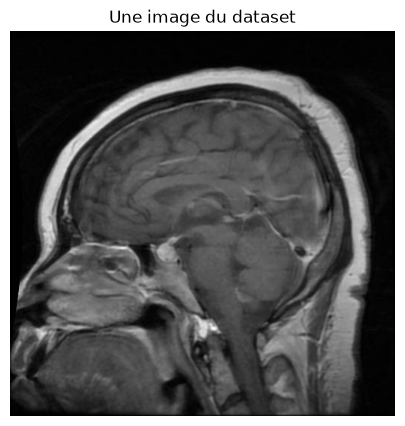

In [157]:
plt.figure(figsize=(5, 5))
plt.imshow(pixels)
plt.title("Une image du dataset")
plt.axis("off")
plt.show()

Affichage de quelques exemples de chaque dossier

random.seed(42) permet de retrouver la même sélection si rééxécution

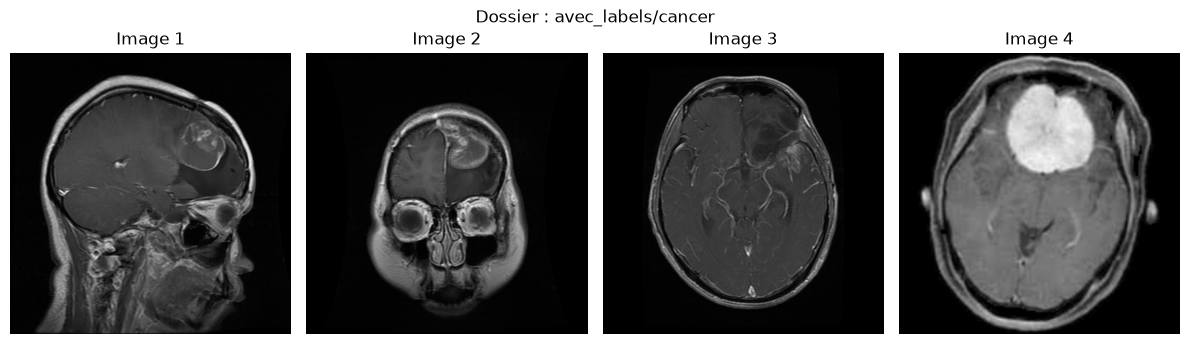

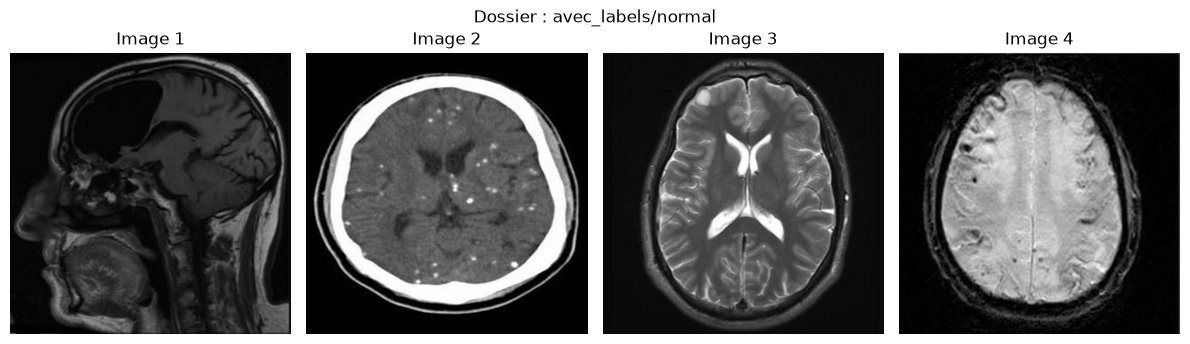

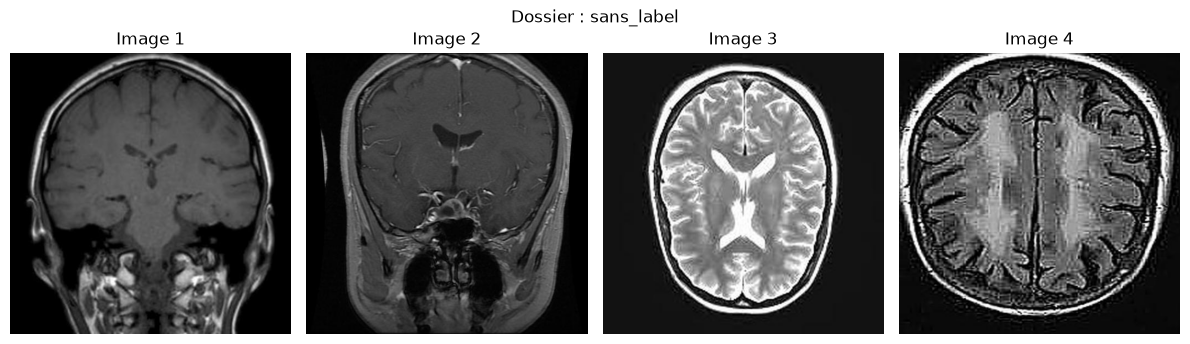

In [158]:
random.seed(42)

for dossier in dossiers:
    fichiers = sorted((dossier_dataset / dossier).glob("*.jpg"))
    exemples = random.sample(fichiers, min(4, len(fichiers)))

    plt.figure(figsize=(12, 3.5))
    for numero, chemin in enumerate(exemples, start=1):
        with Image.open(chemin) as image:
            pixels_exemple = np.array(image)

        plt.subplot(1, 4, numero)
        plt.imshow(pixels_exemple)
        plt.title(f"Image {numero}")
        plt.axis("off")

    plt.suptitle(f"Dossier : {dossier}")
    plt.tight_layout()
    plt.show()

échantillon de 100 images
Vérifications des dimensions, du mode de couleur, du nombre de canaux,
le format et la lisibilité 

In [159]:
random.seed(42)
echantillon = random.sample(chemins_images, min(100, len(chemins_images)))

print("Nombre d'images à vérifier :", len(echantillon))

Nombre d'images à vérifier : 100


Pour chaque fichier, appel de `image.load()` pour lire
ses pixels. Ses caractéristiques sont ajoutées à une liste.

In [160]:
caracteristiques = []
erreurs = []

for chemin in echantillon:
    try:
        with Image.open(chemin) as image:
            image.load()
            caracteristiques.append({
                "Fichier": chemin.name,
                "Dossier": str(chemin.parent.relative_to(dossier_dataset)),
                "Largeur": image.width,
                "Hauteur": image.height,
                "Mode": image.mode,
                "Canaux": len(image.getbands()),
                "Format": image.format,
            })
    except OSError as erreur:
        erreurs.append({"Fichier": str(chemin), "Erreur": str(erreur)})

controle = pd.DataFrame(caracteristiques)
display(controle.head())

,Fichier,Dossier,Largeur,Hauteur,Mode,Canaux,Format
0,de4a58ef-0572-499a-8b39-437d6605102e.jpg,sans_label,512,512,RGB,3,JPEG
1,1567a15d-5f22-46ca-a77c-cd88ee60b7fd.jpg,sans_label,512,512,RGB,3,JPEG
2,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,avec_labels/normal,512,512,RGB,3,JPEG
3,5674a7bf-6fe6-4c43-b574-fdd81608e18b.jpg,sans_label,512,512,RGB,3,JPEG
4,4a4822ad-22e0-4dac-a072-18fe2824cc9f.jpg,sans_label,512,512,RGB,3,JPEG


Regroupons les images pour vérifier qu'elles ont les mêmes caractéristiques

In [161]:
resume = controle.groupby(["Largeur", "Hauteur", "Mode", "Canaux"]).size()
display(resume.to_frame("Nombre d'images"))
display(controle["Format"].value_counts().to_frame("Nombre d'images"))

print("Images lisibles dans l'échantillon :", len(controle))
print("Erreurs de lecture :", len(erreurs))

if erreurs:
    display(pd.DataFrame(erreurs))

,,,,Nombre d'images
Largeur,Hauteur,Mode,Canaux,
512,512,RGB,3,100


,Nombre d'images
Format,
JPEG,100


Images lisibles dans l'échantillon : 100
Erreurs de lecture : 0


Recherche de doublons

In [162]:


images_vues = {}
doublons = []

for chemin in chemins_images:
    with Image.open(chemin) as image:
        image_rgb = image.convert("RGB")
        empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
        signature = (image_rgb.size, empreinte)

    if signature in images_vues:
        doublons.append((images_vues[signature], chemin))
    else:
        images_vues[signature] = chemin

print("Nombre d'images examinées :", len(chemins_images))
print("Nombre de copies supplémentaires :", len(doublons))

display(pd.DataFrame(doublons, columns=["Première image", "Copie"]))

Nombre d'images examinées : 1506
Nombre de copies supplémentaires : 96


,Première image,Copie
0,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/avec_labels/normal...
1,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/04dd2b7...
2,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/16a1699...
3,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/18599c4...
4,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/194106c...
...,...,...
91,mri_dataset_brain_cancer_oc/sans_label/1212636...,mri_dataset_brain_cancer_oc/sans_label/f84cb0d...
92,mri_dataset_brain_cancer_oc/avec_labels/cancer...,mri_dataset_brain_cancer_oc/sans_label/f946618...
93,mri_dataset_brain_cancer_oc/sans_label/abac225...,mri_dataset_brain_cancer_oc/sans_label/fa8ec37...
94,mri_dataset_brain_cancer_oc/sans_label/f9d60d2...,mri_dataset_brain_cancer_oc/sans_label/fcf1c2e...


regroupons e simages par dossier

In [163]:
fichiers_concernes = set()

for premiere_image, copie in doublons:
    fichiers_concernes.add(premiere_image)
    fichiers_concernes.add(copie)

dossiers_doublons = pd.Series(
    [chemin.parent.name for chemin in fichiers_concernes],
    name="Dossier"
)

classement = dossiers_doublons.value_counts()
classement = classement.reindex(
    ["sans_label", "cancer", "normal"], fill_value=0
)

display(classement.to_frame("Fichiers concernés"))

,Fichiers concernés
Dossier,
sans_label,154
cancer,8
normal,24


On effectue la recherche de doublons par dossier cette fois ci

In [164]:


for dossier in ["sans_label", "avec_labels/cancer", "avec_labels/normal"]:
    images_vues = {}
    doublons_dossier = []

    chemins = sorted((dossier_dataset / dossier).glob("*.jpg"))

    for chemin in chemins:
        with Image.open(chemin) as image:
            image_rgb = image.convert("RGB")
            empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
            signature = (image_rgb.size, empreinte)

        if signature in images_vues:
            doublons_dossier.append((images_vues[signature], chemin))
        else:
            images_vues[signature] = chemin

    print(f"{dossier} : {len(doublons_dossier)} copie(s) supplémentaire(s)")

    if doublons_dossier:
        display(pd.DataFrame(
            doublons_dossier,
            columns=["Première image", "Copie"]
        ))

sans_label : 64 copie(s) supplémentaire(s)


,Première image,Copie
0,mri_dataset_brain_cancer_oc/sans_label/11c7876...,mri_dataset_brain_cancer_oc/sans_label/21797d4...
1,mri_dataset_brain_cancer_oc/sans_label/01d4471...,mri_dataset_brain_cancer_oc/sans_label/3a1ca11...
2,mri_dataset_brain_cancer_oc/sans_label/3058ed0...,mri_dataset_brain_cancer_oc/sans_label/3a57247...
3,mri_dataset_brain_cancer_oc/sans_label/1d9eb25...,mri_dataset_brain_cancer_oc/sans_label/4ab4a1f...
4,mri_dataset_brain_cancer_oc/sans_label/070e468...,mri_dataset_brain_cancer_oc/sans_label/55e150d...
...,...,...
59,mri_dataset_brain_cancer_oc/sans_label/9f94cc0...,mri_dataset_brain_cancer_oc/sans_label/f5b5021...
60,mri_dataset_brain_cancer_oc/sans_label/1212636...,mri_dataset_brain_cancer_oc/sans_label/f84cb0d...
61,mri_dataset_brain_cancer_oc/sans_label/abac225...,mri_dataset_brain_cancer_oc/sans_label/fa8ec37...
62,mri_dataset_brain_cancer_oc/sans_label/f9d60d2...,mri_dataset_brain_cancer_oc/sans_label/fcf1c2e...


avec_labels/cancer : 0 copie(s) supplémentaire(s)
avec_labels/normal : 1 copie(s) supplémentaire(s)


,Première image,Copie
0,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/avec_labels/normal...


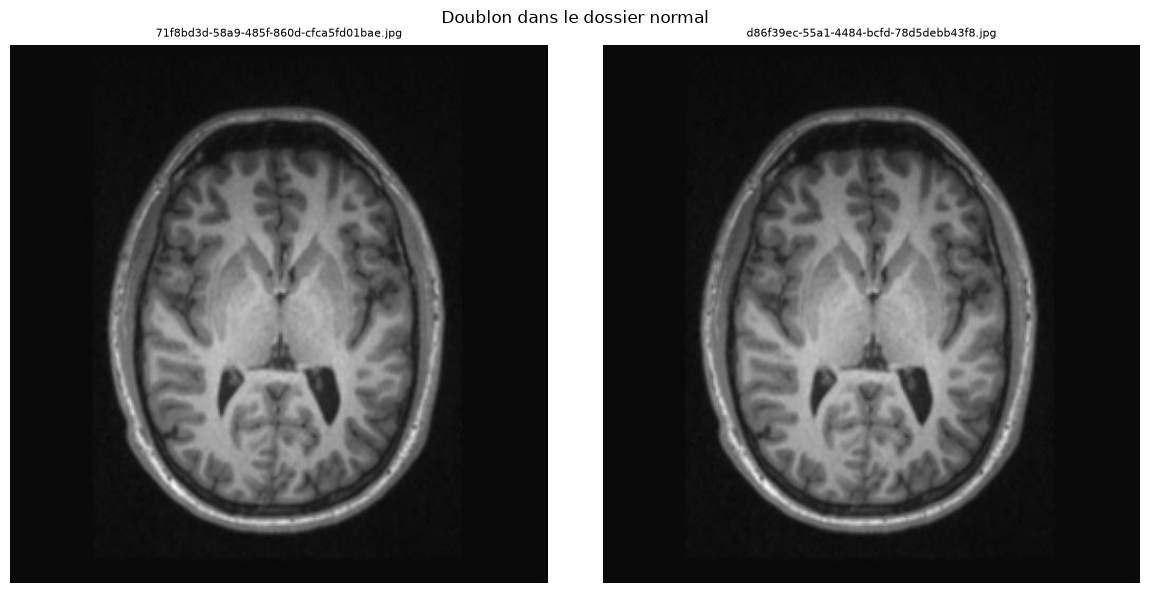

In [165]:
dossier_normal = Path("mri_dataset_brain_cancer_oc/avec_labels/normal")

fichiers = [
    "71f8bd3d-58a9-485f-860d-cfca5fd01bae.jpg",
    "d86f39ec-55a1-4484-bcfd-78d5debb43f8.jpg",
]

plt.figure(figsize=(12, 6))

for numero, nom in enumerate(fichiers, start=1):
    with Image.open(dossier_normal / nom) as image:
        plt.subplot(1, 2, numero)
        plt.imshow(image)

    plt.title(nom, fontsize=8)
    plt.axis("off")

plt.suptitle("Doublon dans le dossier normal")
plt.tight_layout()
plt.show()

Conclusion

- Le comptage donne **1 506 images JPEG** : 50 dans cancer, 50 dans normal
  et 1 406 dans sans_label.
- Les deux classes étiquetées sont équilibrées. 
- Le dossier sans label contient **six images de plus** qque l'enoncé
- Les **100 images contrôlées** mesurent **512 × 512 pixels** et sont stockées
  en **RGB, avec trois canaux**.
- Aucune erreur de lecture n'a été rencontrée dans cet échantillon.
- Les images montrent différentes orientations de coupe et différents cadrages.
- La place occupée par le cerveau, le contraste et la netteté apparente varient.
- Les exemples apparaissent principalement en niveaux de gris malgré le stockage RGB.
- Une même taille de 512 × 512 pixels ne garantit pas une qualité visuelle uniforme.
- Le data set contient des doublons:
  - 96 au total sur le set global
  - 1 dans le dossier lablélisé: Normal
  
  --> Ces doublons seront à traiter

Traitement des doublons

In [166]:
nombre_images_avant = len(chemins_images)

# Récupérer les chemins des copies supplémentaires.
copies_a_ecarter = {
    copie for premiere_image, copie in doublons
}

# Conserver uniquement la première occurrence de chaque image.
chemins_images = [
    chemin for chemin in chemins_images
    if chemin not in copies_a_ecarter
]

print("Images avant filtrage :", nombre_images_avant)
print("Copies écartées :", nombre_images_avant - len(chemins_images))
print("Images conservées pour l'étape 2 :", len(chemins_images))

Images avant filtrage : 1506
Copies écartées : 96
Images conservées pour l'étape 2 : 1410


## Etape 2: Prétraitement et extraction des features


Choix d'une version préentrainé de ResNet18: IMAGENET1K_V1
définition de la focntion prétraitement qui réalisera le redimensionnement des images, le recadrage, la conversion et la normalisation


In [167]:


poids = models.ResNet18_Weights.IMAGENET1K_V1
pretraitement = poids.transforms()
print(pretraitement)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Application de "pretraitement" à chaque image du dataset
Stockage du resultat dans la liste images_preparees


In [168]:
images_preparees = []

for chemin in chemins_images:
    image = read_image(str(chemin), mode=ImageReadMode.RGB)
    images_preparees.append(pretraitement(image))

print("Nombre d'images préparées :", len(images_preparees))
print("Forme d'une image préparée :", tuple(images_preparees[0].shape))
print("Type des valeurs :", images_preparees[0].dtype)

Nombre d'images préparées : 1410
Forme d'une image préparée : (3, 224, 224)
Type des valeurs : torch.float32


Chargement de ResNet avec le poids préentrainé précédement choisi
Gel des couches convutionelles avec `requires_grad = False` (cela gele tous les paramètres du modele, y compris les couches convutionelles donc cela repond à notre bespoin)

On prépare le modèle pour renvoyer les 512 nombres décrivant l’image avec identity(), puis modele.eval() pour utiliser le modele déjà entrainé

pui son verifie que les couches sont bien gelées en verifiant les paramètre entrainabels

In [169]:
modele = models.resnet18(weights=poids)

for parametre in modele.parameters():
    parametre.requires_grad = False

modele.fc = torch.nn.Identity()
modele.eval()

print("Nombre de paramètres entraînables :", sum(
    parametre.numel() for parametre in modele.parameters() if parametre.requires_grad
))

Nombre de paramètres entraînables : 0


Extractions des embeddings des images préparés:
- On traite les images préparées par lots de 16 : pour chaque image, le modèle crée un vecteur de 512 nombres décrivant l’image.
- On ajoute avec append() chaque lot de 16 vecteurs dans blocs_features.
- Après la boucle, on concatène avec np.concatenate() les blocs en un tableau unique.

In [170]:
taille_lot = 16
blocs_features = []

for debut in range(0, len(images_preparees), taille_lot):
    images_lot = images_preparees[debut:debut + taille_lot]
    lot = torch.stack(images_lot)
    features_lot = modele(lot).numpy()
    blocs_features.append(features_lot)

    nombre_traite = debut + len(images_lot)
    if debut % (taille_lot * 10) == 0 or nombre_traite == len(images_preparees):
        print(f"Images traitées : {nombre_traite} / {len(images_preparees)}")

matrice_features = np.concatenate(blocs_features, axis=0)
print("Forme de la matrice de features :", matrice_features.shape)

Images traitées : 16 / 1410
Images traitées : 176 / 1410
Images traitées : 336 / 1410
Images traitées : 496 / 1410
Images traitées : 656 / 1410
Images traitées : 816 / 1410
Images traitées : 976 / 1410
Images traitées : 1136 / 1410
Images traitées : 1296 / 1410
Images traitées : 1410 / 1410
Forme de la matrice de features : (1410, 512)



Transformation de matrice_features en tableau pandas nommé features avec les colonnes de features numériques nommées feature_000 à feature_511.

La premiere colonne du tableau contient le chemin relatif de l'image

In [171]:
colonnes_features = [f"feature_{numero:03d}" for numero in range(512)]
features = pd.DataFrame(matrice_features, columns=colonnes_features)
features.insert(0, "chemin", [
    chemin.relative_to(dossier_dataset).as_posix() for chemin in chemins_images
])

print("Forme du tableau :", features.shape)
display(features.head())

Forme du tableau : (1410, 513)


,chemin,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,avec_labels/cancer/05340cd4-3bb2-459d-9937-bf2...,0.182118,0.333518,1.282342,0.834789,1.378281,0.484790,2.094169,0.158858,0.419732,...,0.036741,0.564865,0.443068,0.854441,1.457598,0.201099,0.316057,0.211322,0.390608,0.708158
1,avec_labels/cancer/0c6f3641-60d9-4a76-abe5-de8...,2.266326,1.162453,1.918435,2.012136,1.693995,0.137189,1.577458,0.216767,1.499850,...,0.310547,0.267448,3.290416,0.624881,1.411666,1.611988,0.535143,0.598020,0.040257,1.162966
2,avec_labels/cancer/0f718241-8f63-4b55-81ce-315...,4.595700,1.165719,0.881030,0.903633,1.555227,0.086425,1.360634,0.000000,1.339879,...,0.452656,0.895471,1.856983,0.600913,2.108837,2.697287,0.648695,1.338270,0.041187,0.565739
3,avec_labels/cancer/11a7a426-4806-401e-98b2-b96...,1.982301,1.395936,1.432251,0.519939,0.580916,0.160166,3.397490,0.003394,2.662047,...,1.137100,0.316018,4.567581,1.865795,1.694037,1.388204,0.114191,0.154368,1.244824,1.034642
4,avec_labels/cancer/1c043dbb-4623-4769-8e5e-022...,2.520188,0.711255,0.919493,1.350703,2.717374,0.066807,1.882675,0.078474,0.076435,...,0.355171,0.073457,1.313526,0.581309,0.367498,0.784860,0.410580,1.877233,0.000000,1.895125


## Etape 3: modélisation non supervisée



Standardisation des features avec StandardScaler


In [172]:
# La standardisation utilise les features des deux ensembles, sans leurs labels.
X_features = features[colonnes_features]
standardisation = StandardScaler()
X_standardise = standardisation.fit_transform(X_features)

print("Forme des features standardisées (fortes et sans label) :", X_standardise.shape)
display(pd.DataFrame(X_standardise, columns=colonnes_features).head())

Forme des features standardisées (fortes et sans label) : (1410, 512)


,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,-1.523923,-0.566209,-0.058269,-0.707910,0.647204,0.683567,-0.595109,-0.169444,-0.788826,-0.226437,...,-1.027782,-0.330129,-1.278363,-0.308692,0.247902,-1.311877,0.092423,-0.716462,0.168135,-0.606535
1,0.437962,1.206399,0.883810,1.312549,1.065704,-0.392132,-1.147922,0.033440,0.773705,-0.164565,...,-0.399214,-0.823909,1.452051,-0.656769,0.178910,0.614751,0.778879,0.014371,-0.736078,0.020451
2,2.630623,1.213383,-0.652628,-0.589766,0.881758,-0.549229,-1.379895,-0.726001,0.542285,0.455524,...,-0.072979,0.218754,0.077486,-0.693111,1.226085,2.096772,1.134669,1.413391,-0.733679,-0.802871
3,0.170606,1.705683,0.163752,-1.248227,-0.409755,-0.321028,0.799272,-0.714111,2.454973,1.558210,...,1.498278,-0.743271,2.676765,1.224799,0.603041,0.309165,-0.540077,-0.824102,2.372762,-0.156453
4,0.676924,0.241551,-0.595664,0.177457,2.422259,-0.609940,-0.821380,-0.451067,-1.285449,1.740837,...,-0.296774,-1.145979,-0.443652,-0.722836,-1.389467,-0.514727,0.388591,2.431994,-0.839978,1.029787


Réducitond es dimensions en utilisant la fonction fit_transform de PCA

In [173]:
# La PCA utilise toutes les features standardisées, sans utiliser les labels.
pca = PCA(n_components=2, random_state=42)
X_pca_complet = pca.fit_transform(X_standardise)


Séparation des images:
- donnees_fortes=features des images labalisées + une colone indiquant le label
- donnees_sans_label: Feature des images NON lablisées
- X_fort_pca: Coordonées PCA des image labelisée
- X_pca :  Coordonées PCA des image NON labelisée

In [174]:
# Séparer les images une seule fois, après la préparation commune.
masque_fort = features["chemin"].str.startswith("avec_labels/")
masque_sans_label = features["chemin"].str.startswith("sans_label/")

# Garder les features et les labels forts dans leur propre tableau.
donnees_fortes = features.loc[masque_fort].copy()
donnees_fortes["label_fort"] = donnees_fortes["chemin"].str.split("/").str[1]
donnees_sans_label = features.loc[masque_sans_label].copy()

# Séparer aussi les coordonnées PCA, dans le même ordre que les tableaux.
X_fort_pca = X_pca_complet[masque_fort.to_numpy()]
X_pca = X_pca_complet[masque_sans_label.to_numpy()]

print("Images avec un label connu :", len(donnees_fortes))
print("Images sans label :", len(donnees_sans_label))

Images avec un label connu : 99
Images sans label : 1311


Réalisation du clustering avec K-Means

- n_clusters=2 pour la spération en deux groupes, comme pour le dataset labélisé
- random_state=42 pour pouvori reproduirele clustering.


In [175]:
# X_pca contient uniquement les coordonnées des images sans label.
kmeans = KMeans(n_clusters=2, random_state=42)
groupes_kmeans_sans_label = kmeans.fit_predict(X_pca)

display(pd.Series(groupes_kmeans_sans_label).value_counts().sort_index().to_frame("Nombre d'images"))

,Nombre d'images
0,719
1,592


Graphique illustrant les coordonées des images

Chaque point représente une image, placée selon ses deux coordonnées PCA. Sa couleur indique le groupe attribué par K-Means.

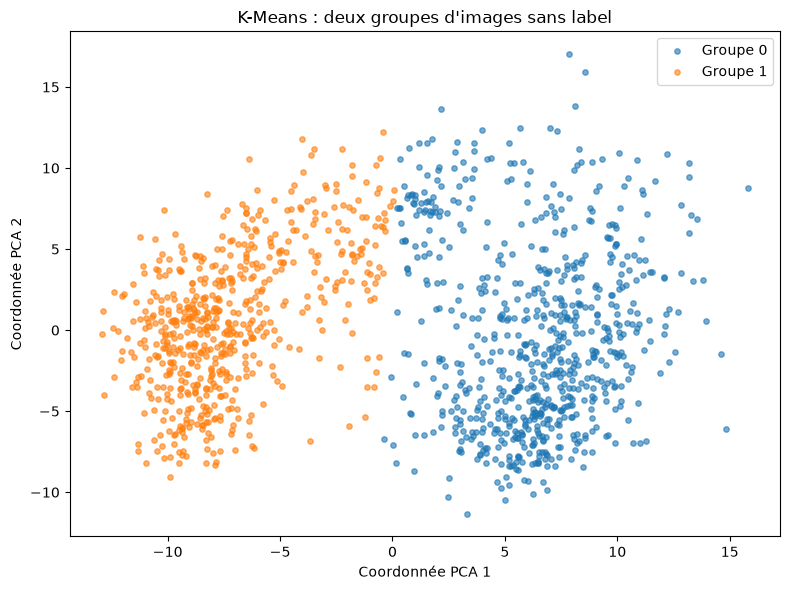

In [176]:
plt.figure(figsize=(8, 6))

for groupe in [0, 1]:
    selection = groupes_kmeans_sans_label == groupe
    plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                s=15, alpha=0.6, label=f"Groupe {groupe}")

plt.xlabel("Coordonnée PCA 1")
plt.ylabel("Coordonnée PCA 2")
plt.title("K-Means : deux groupes d'images sans label")
plt.legend()
plt.tight_layout()
plt.show()

K-Means répartit les images en deux groupes, principalement séparés par l'abscisse PCA (gauche vs droite). Les groupes présentent une dispersion interne. Cette représentation montre des différences entre les images, sans pour autant identifier chaque groupe comme étant: « normal » et « cancer ».

Réalisation du clustering avec DBSCAN

Choix de neuf combinaisaon à tester pour visualiser ensutie les resultats:
- eps (rayon du voisinage ): 0.5, 1.0, 2.0
- et repectivement min_samples (nombre minimum de points dans ce voisinage): 3, 5, 10.  ;

Chaque résultat est conservé dans essais_dbscan avec ses paramètres, ses numéros de groupes, le nombre de groupes et le nombre d'images hors groupe (-1).

In [177]:
# Les neuf essais utilisent uniquement les images sans label de X_pca.
essais_dbscan = []

for eps in [0.5, 1.0, 2.0]:
    for min_samples in [3, 5, 10]:
        dbscan_essai = DBSCAN(eps=eps, min_samples=min_samples)
        groupes_essai = dbscan_essai.fit_predict(X_pca)
        nombre_groupes_essai = len(set(groupes_essai) - {-1})
        nombre_hors_groupe_essai = int((groupes_essai == -1).sum())

        essais_dbscan.append({
            "eps": eps,
            "min_samples": min_samples,
            "groupes": groupes_essai,
            "nombre_groupes": nombre_groupes_essai,
            "nombre_hors_groupe": nombre_hors_groupe_essai,
        })

        print(f"eps={eps}, min_samples={min_samples} : "
              f"{nombre_groupes_essai} groupe(s), "
              f"{nombre_hors_groupe_essai} image(s) hors groupe")


eps=0.5, min_samples=3 : 70 groupe(s), 269 image(s) hors groupe
eps=0.5, min_samples=5 : 34 groupe(s), 529 image(s) hors groupe
eps=0.5, min_samples=10 : 14 groupe(s), 1062 image(s) hors groupe
eps=1.0, min_samples=3 : 8 groupe(s), 44 image(s) hors groupe
eps=1.0, min_samples=5 : 6 groupe(s), 84 image(s) hors groupe
eps=1.0, min_samples=10 : 5 groupe(s), 277 image(s) hors groupe
eps=2.0, min_samples=3 : 1 groupe(s), 5 image(s) hors groupe
eps=2.0, min_samples=5 : 1 groupe(s), 6 image(s) hors groupe
eps=2.0, min_samples=10 : 1 groupe(s), 13 image(s) hors groupe


Affichage d'un graphique pour chaque essai de paramètre avec DBSCAN: Une couleur représente chaque groupe ; les points hors groupe (`-1`) sont affichés en gris.



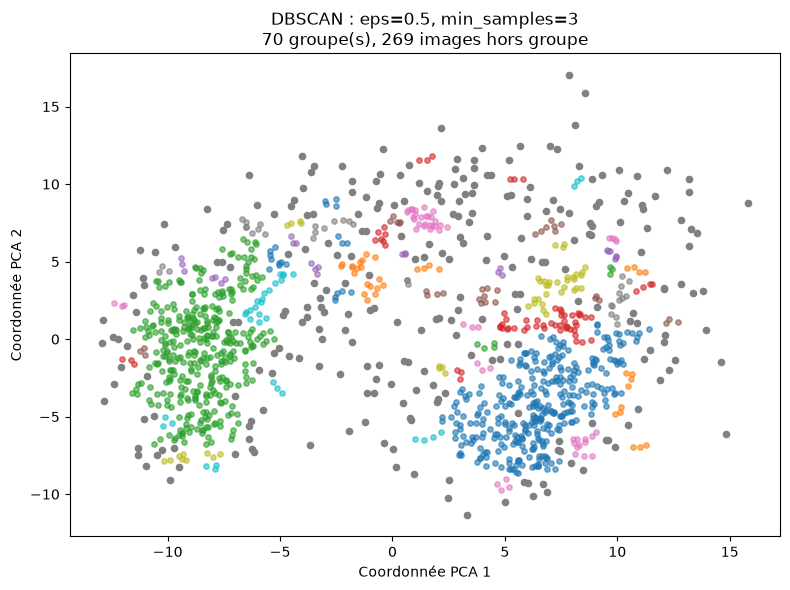

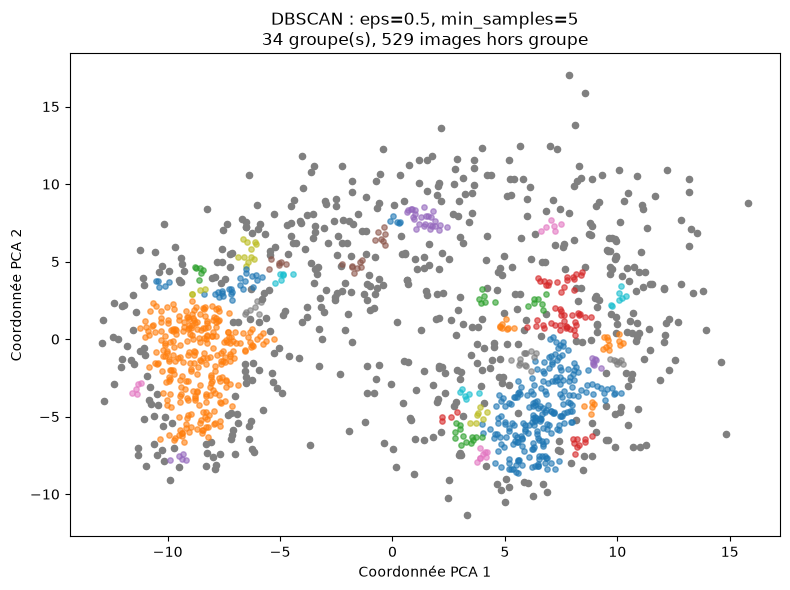

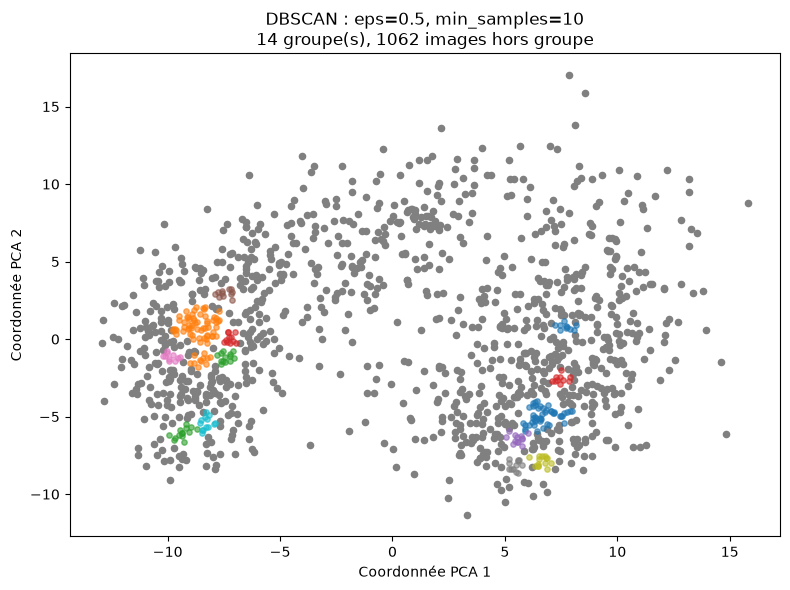

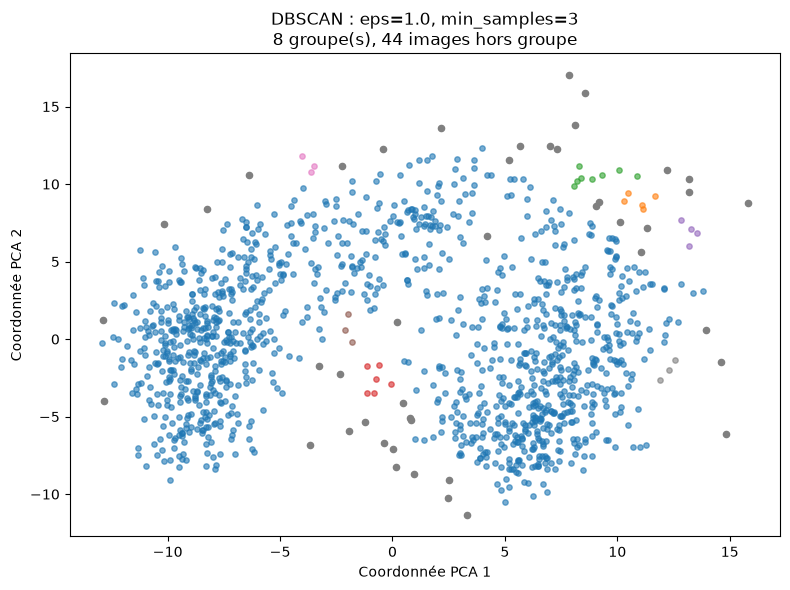

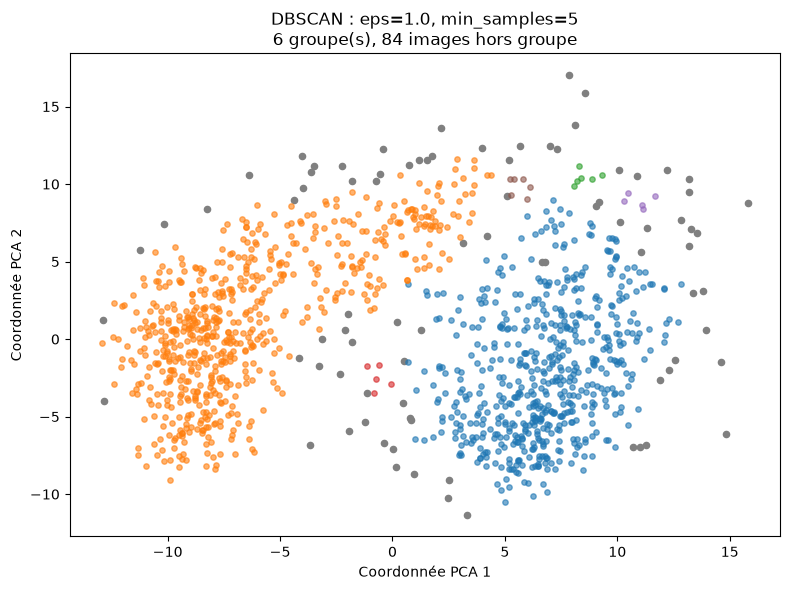

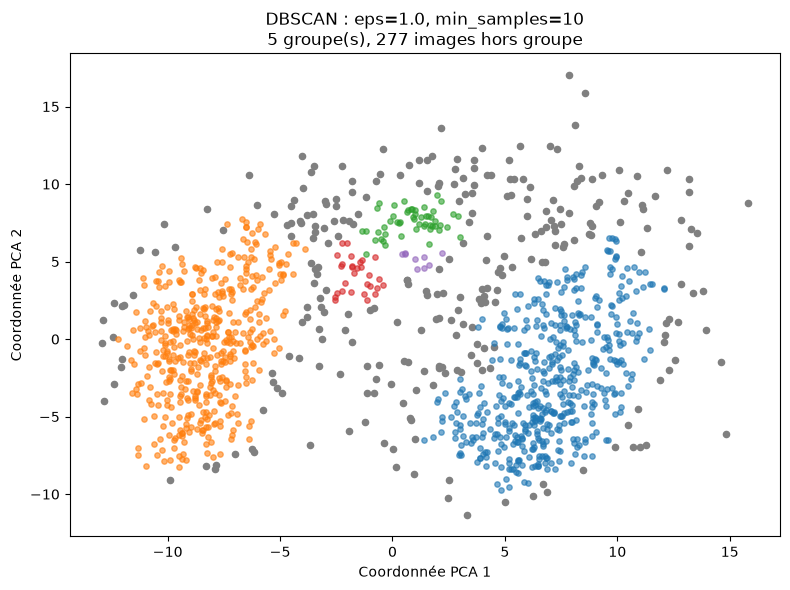

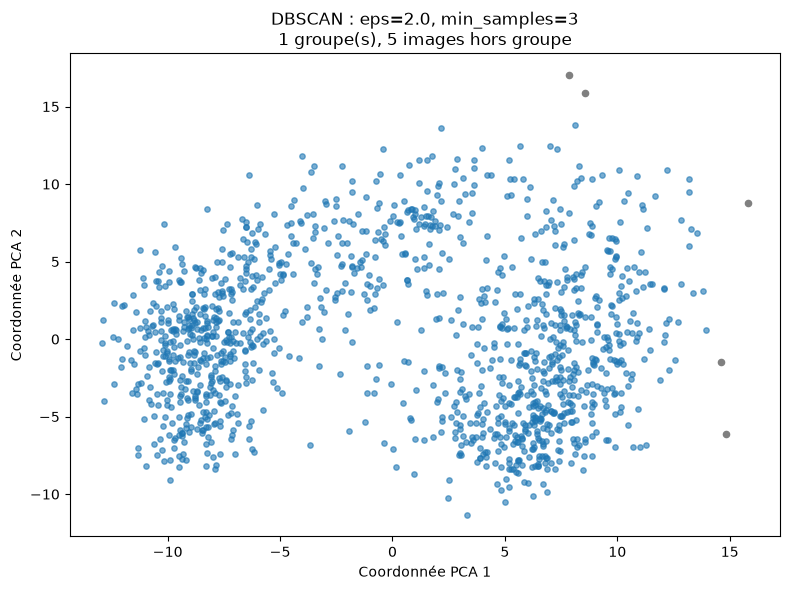

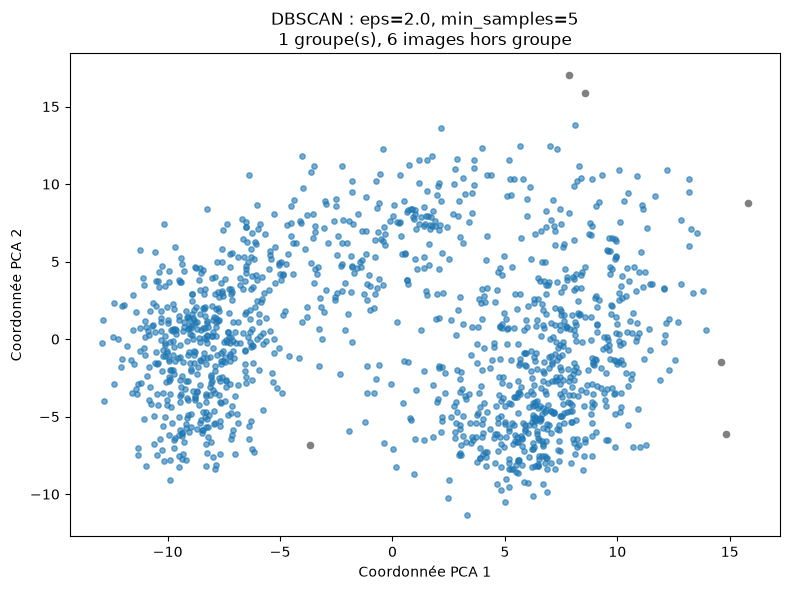

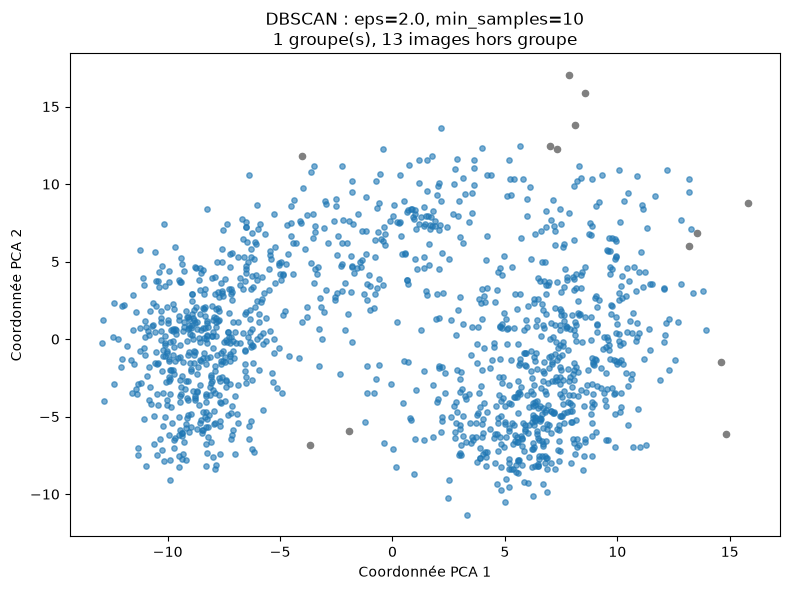

In [178]:
for essai in essais_dbscan:
    groupes_essai = essai["groupes"]
    plt.figure(figsize=(8, 6))

    for groupe in sorted(set(groupes_essai)):
        selection = groupes_essai == groupe
        if groupe == -1:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=20, color="gray", label="Hors groupe (-1)")
        else:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=15, alpha=0.6, label=f"Groupe {groupe}")

    plt.xlabel("Coordonnée PCA 1")
    plt.ylabel("Coordonnée PCA 2")
    plt.title(
        f"DBSCAN : eps={essai['eps']}, min_samples={essai['min_samples']}\n"
        f"{essai['nombre_groupes']} groupe(s), "
        f"{essai['nombre_hors_groupe']} images hors groupe"
    )
    plt.tight_layout()
    plt.show()

Avec les paramètres testés, DBSCAN produit un nombre de groupes différent des deux groupes demandés, ainsi que des images hors groupe. Je l’écarte donc pour la labellisation faible et je conserve K-Means, qui répartit les images en deux groupes.

Comparaison de K-Means et les neuf essais DBSCAN avec l'ARI

Comparaison avec le groupe aux labels des 100 images étiquetées'utilisation de donnees_fortes et de masque_fort. Les images sans label ne participent pas au calcul du score.

L'**ARI** mesure l'accord entre deux regroupements


In [179]:
# Utiliser les coordonnées fortes déjà séparées après la PCA.
labels_reference = donnees_fortes["label_fort"].to_numpy()

# Attribuer un groupe aux images fortes sans réentraîner K-Means.
groupes_kmeans_forts = kmeans.predict(X_fort_pca)

# Comparer les groupes et les vrais labels des mêmes images, dans le même ordre.
ari_kmeans = adjusted_rand_score(labels_reference, groupes_kmeans_forts)

scores_ari = pd.DataFrame({
    "Méthode": ["K-Means"],
    "ARI sur les labels connus": [ari_kmeans],
})
display(scores_ari)

# Garder les numéros de groupes par indice pour le code existant de l'étape 4.
groupes_kmeans = pd.Series(index=features.index, dtype="Int64")
groupes_kmeans.loc[donnees_sans_label.index] = groupes_kmeans_sans_label
groupes_kmeans.loc[donnees_fortes.index] = groupes_kmeans_forts


,Méthode,ARI sur les labels connus
0,K-Means,0.349172


KMEANS représente le meilleur score ARI donc nous utilison sle classement de cette méthode

Le code copie donnees_sans_label dans donnees_faibles, puis ajoute la colonne label_faible. Les valeurs 0 et 1 sont les numéros des groupes K-Means ; elles ne signifient pas automatiquement « normal » et « cancer ».
Les données fortement labellisées restent dans un tableau séparé.

In [180]:
donnees_faibles = donnees_sans_label.copy()
donnees_faibles["label_faible"] = groupes_kmeans_sans_label

print("Méthode utilisée pour les labels faibles : K-Means")
print("Images fortement labellisées, conservées séparément :", len(donnees_fortes))
print("Images faiblement labellisées :", len(donnees_faibles))
display(donnees_faibles[["chemin", "label_faible"]].head())
display(donnees_faibles["label_faible"].value_counts().sort_index().to_frame("Nombre d'images"))

Méthode utilisée pour les labels faibles : K-Means
Images fortement labellisées, conservées séparément : 99
Images faiblement labellisées : 1311


,chemin,label_faible
99,sans_label/001b158a-7af8-451e-bf31-3a9116265f3...,0
100,sans_label/00366e8d-5520-4d3c-a70b-91a7eec1f52...,1
101,sans_label/00455a62-f79f-4072-9a23-4951e759acd...,1
102,sans_label/004ce5f5-ca6b-490f-9b2f-c322c152e2e...,1
103,sans_label/005d9a37-8894-4eb5-8367-1015d4a4363...,0


,Nombre d'images
label_faible,
0,719
1,592


## Étape 4 : entraînement du CNN



Séparation du jeu d'entrainement et de test

In [181]:
faibles_train, faibles_test = train_test_split(
    donnees_faibles,
    test_size=0.2,
    stratify=donnees_faibles["label_faible"],
    random_state=42,
)
fortes_train, fortes_test = train_test_split(
    donnees_fortes,
    test_size=0.2,
    stratify=donnees_fortes["label_fort"],
    random_state=42,
)

effectifs_faibles = pd.DataFrame({
    "Entraînement faible": faibles_train["label_faible"].value_counts(),
    "Test faible": faibles_test["label_faible"].value_counts(),
}).reindex([0, 1]).fillna(0).astype(int)

effectifs_forts = pd.DataFrame({
    "Entraînement fort": fortes_train["label_fort"].value_counts(),
    "Test fort": fortes_test["label_fort"].value_counts(),
}).reindex(["normal", "cancer"]).fillna(0).astype(int)

display(effectifs_faibles)
display(effectifs_forts)


,Entraînement faible,Test faible
label_faible,,
0,575,144
1,473,119


,Entraînement fort,Test fort
label_fort,,
normal,39,10
cancer,40,10


Mise en forme des donnes pour le CNN:
- On associe chaque image à son étiquette.
- On prépare les chargeurs qui distribueront ces couples.

In [182]:
faibles_train["cible"] = faibles_train["label_faible"].astype(int)
faibles_test["cible"] = faibles_test["label_faible"].astype(int)
fortes_train["cible"] = fortes_train["label_fort"].map({"normal": 0, "cancer": 1})
fortes_test["cible"] = fortes_test["label_fort"].map({"normal": 0, "cancer": 1})

taille_lot_etape4 = 16
epoques_faibles = 5
epoques_fortes = 5
taux_apprentissage = 0.001
appareil_etape4 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

positions_images = {
    chemin.relative_to(dossier_dataset).as_posix(): position
    for position, chemin in enumerate(chemins_images)
}

def creer_chargeur(tableau, melanger):
    images = torch.stack([
        images_preparees[positions_images[chemin]]
        for chemin in tableau["chemin"]
    ])
    cibles = torch.tensor(tableau["cible"].to_numpy(), dtype=torch.long)
    dataset = TensorDataset(images, cibles)
    return DataLoader(
        dataset,
        batch_size=taille_lot_etape4,
        shuffle=melanger,
        generator=torch.Generator().manual_seed(42),
    )

chargeur_faible = creer_chargeur(faibles_train, melanger=True)
chargeur_test_faible = creer_chargeur(faibles_test, melanger=False)
chargeur_fort = creer_chargeur(fortes_train, melanger=True)
chargeur_test = creer_chargeur(fortes_test, melanger=False)

print("Lots d'entraînement faible :", len(chargeur_faible))
print("Lots de test faible :", len(chargeur_test_faible))
print("Lots d'entraînement fort :", len(chargeur_fort))
print("Lots de test fort :", len(chargeur_test))
print("Appareil utilisé :", appareil_etape4)


Lots d'entraînement faible : 66
Lots de test faible : 17
Lots d'entraînement fort : 5
Lots de test fort : 2
Appareil utilisé : cpu


Creation de deux CNN:
- Un pour l'entraienment semi-supervisé
- un pour l'entrainement supervisé

On utilise le même poids (utilisé en etape 2)

In [183]:
def creer_cnn():
    torch.manual_seed(42)
    cnn = models.resnet18(weights=poids)
    for parametre in cnn.parameters():
        parametre.requires_grad = False
    cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
    return cnn.to(appareil_etape4)

modele_semi = creer_cnn()
modele_supervise = creer_cnn()
fonction_perte = torch.nn.CrossEntropyLoss()

optimiseur_semi = torch.optim.Adam(
    modele_semi.fc.parameters(), lr=taux_apprentissage
)
optimiseur_supervise = torch.optim.Adam(
    modele_supervise.fc.parameters(), lr=taux_apprentissage
)

for nom, cnn in [("Semi-supervisé", modele_semi), ("Supervisé", modele_supervise)]:
    print(nom, ": paramètres entraînables =", sum(
        parametre.numel() for parametre in cnn.parameters()
        if parametre.requires_grad
    ))


Semi-supervisé : paramètres entraînables = 1026
Supervisé : paramètres entraînables = 1026


Creation de 2 fonctions:
- entrainer_cnn qui entraine le CNN en ajustnat le poids de la coiche finale et qui affiche la perte moyenne à chaque époque
- evaluer_cnn fera les prédictions sur un test sans modifier les poids. L'evaluation se fait avec l'accuracy, le F1 score et la matrice de confusion


In [184]:
def entrainer_cnn(cnn, chargeur, optimiseur, nombre_epoques):
    chargeur.generator.manual_seed(42)
    pertes = []

    for epoque in range(nombre_epoques):
        cnn.eval()
        cnn.fc.train()
        perte_totale = 0.0

        for images_lot, cibles_lot in chargeur:
            images_lot = images_lot.to(appareil_etape4)
            cibles_lot = cibles_lot.to(appareil_etape4)

            optimiseur.zero_grad()
            sorties = cnn(images_lot)
            perte = fonction_perte(sorties, cibles_lot)
            perte.backward()
            optimiseur.step()
            perte_totale += perte.item() * len(cibles_lot)

        perte_moyenne = perte_totale / len(chargeur.dataset)
        pertes.append(perte_moyenne)
        print(f"Époque {epoque + 1}/{nombre_epoques} : perte = {perte_moyenne:.4f}")

    return pertes

def evaluer_cnn(cnn, chargeur):
    cnn.eval()
    matrice = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for images_lot, cibles_lot in chargeur:
            sorties = cnn(images_lot.to(appareil_etape4))
            predictions = sorties.argmax(dim=1).cpu()
            for vraie_classe, classe_predite in zip(
                cibles_lot.tolist(), predictions.tolist()
            ):
                matrice[vraie_classe, classe_predite] += 1

    vrais_negatifs, faux_positifs, faux_negatifs, vrais_positifs = matrice.ravel()
    denominateur_f1 = 2 * vrais_positifs + faux_positifs + faux_negatifs
    mesures = {
        "Accuracy": (vrais_negatifs + vrais_positifs) / matrice.sum(),
        "F1": 2 * vrais_positifs / denominateur_f1 if denominateur_f1 > 0 else 0.0,
    }
    return mesures, matrice

print("Fonctions d'entraînement et d'évaluation définies.")


Fonctions d'entraînement et d'évaluation définies.


Entrainement sur les labels faibles

In [185]:
pertes_faibles = entrainer_cnn(
    modele_semi, chargeur_faible, optimiseur_semi, epoques_faibles
)
mesures_faibles, confusion_faibles = evaluer_cnn(
    modele_semi, chargeur_test_faible
)

display(pd.DataFrame(
    [mesures_faibles], index=["Test faible : groupes K-Means"]
).rename(columns={"F1": "F1 groupe 1"}).round(3))


Époque 1/5 : perte = 0.2982
Époque 2/5 : perte = 0.0902
Époque 3/5 : perte = 0.0710
Époque 4/5 : perte = 0.0558
Époque 5/5 : perte = 0.0515


,Accuracy,F1 groupe 1
Test faible : groupes K-Means,0.992,0.992


Conevation du modele_semi et entraienemnt sur les données fortes
puis evaluaiton

In [186]:
pertes_semi = entrainer_cnn(
    modele_semi, chargeur_fort, optimiseur_semi, epoques_fortes
)
mesures_semi, confusion_semi = evaluer_cnn(modele_semi, chargeur_test)

display(pd.DataFrame(
    [mesures_semi], index=["Semi-supervisé : faible puis fort"]
).rename(columns={"F1": "F1 cancer"}).round(3))


Époque 1/5 : perte = 4.5148
Époque 2/5 : perte = 3.6423
Époque 3/5 : perte = 2.5708
Époque 4/5 : perte = 1.4230
Époque 5/5 : perte = 0.7579


,Accuracy,F1 cancer
Semi-supervisé : faible puis fort,0.7,0.75


Entrainement du modele_supervisé sur les données fortes uniquement
puis evaluation

In [187]:
pertes_supervise = entrainer_cnn(
    modele_supervise, chargeur_fort, optimiseur_supervise, epoques_fortes
)
mesures_supervise, confusion_supervise = evaluer_cnn(
    modele_supervise, chargeur_test
)

display(pd.DataFrame(
    [mesures_supervise], index=["Supervisé : fort uniquement"]
).rename(columns={"F1": "F1 cancer"}).round(3))


Époque 1/5 : perte = 0.6678
Époque 2/5 : perte = 0.5192
Époque 3/5 : perte = 0.4195
Époque 4/5 : perte = 0.3781
Époque 5/5 : perte = 0.3143


,Accuracy,F1 cancer
Supervisé : fort uniquement,0.95,0.947


Comparaison de la methode supervisé et de la methode semi supervisé

,Accuracy,F1 cancer
Semi-supervisé : faible puis fort,0.70,0.750
Supervisé : fort uniquement,0.95,0.947


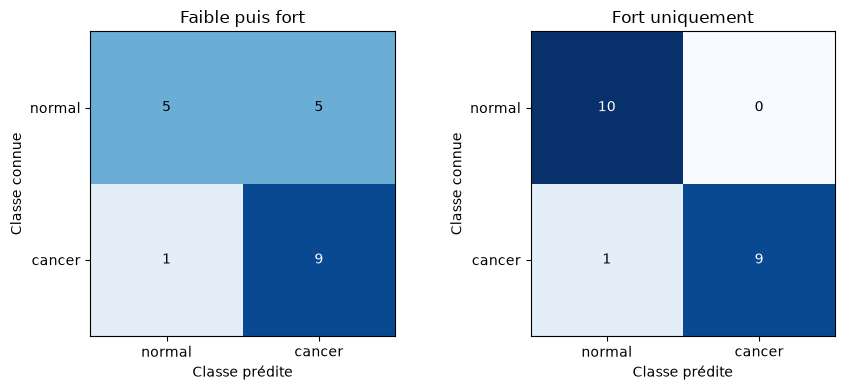

Écart de F1 cancer (semi-supervisé - supervisé) : -0.197
Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.


In [188]:
comparaison_etape4 = pd.DataFrame(
    [mesures_semi, mesures_supervise],
    index=["Semi-supervisé : faible puis fort", "Supervisé : fort uniquement"],
).rename(columns={"F1": "F1 cancer"})
display(comparaison_etape4.round(3))

matrices_etape4 = [confusion_semi, confusion_supervise]
titres_etape4 = ["Faible puis fort", "Fort uniquement"]
maximum_effectifs = max(matrice.max() for matrice in matrices_etape4)
figure, axes = plt.subplots(1, 2, figsize=(9, 4))

for axe, matrice, titre in zip(axes, matrices_etape4, titres_etape4):
    axe.imshow(matrice, cmap="Blues", vmin=0, vmax=maximum_effectifs)
    axe.set_xticks([0, 1], ["normal", "cancer"])
    axe.set_yticks([0, 1], ["normal", "cancer"])
    axe.set_xlabel("Classe prédite")
    axe.set_ylabel("Classe connue")
    axe.set_title(titre)

    for ligne in range(2):
        for colonne in range(2):
            couleur = "white" if matrice[ligne, colonne] > maximum_effectifs / 2 else "black"
            axe.text(
                colonne, ligne, str(matrice[ligne, colonne]),
                ha="center", va="center", color=couleur
            )

plt.tight_layout()
plt.show()

ecart_f1 = mesures_semi["F1"] - mesures_supervise["F1"]
print(f"Écart de F1 cancer (semi-supervisé - supervisé) : {ecart_f1:+.3f}")

if ecart_f1 > 0:
    print("Sur ce test, le modèle semi-supervisé obtient un F1 cancer supérieur.")
elif ecart_f1 < 0:
    print("Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.")
else:
    print("Sur ce test, les deux modèles obtiennent le même F1 cancer.")


In [ ]:
duree_notebook = time.perf_counter() - debut_notebook

print(f"Durée totale : {duree_notebook:.1f} secondes")
print(f"Soit : {duree_notebook / 60:.2f} minutes")